# Marvel superheroes as a social graph

This notebook explores a compact network of 303 Marvel Comics superheroes, connected through their co-occurrence links on Wikipedia pages. What makes this dataset interesting is that it is not a random collection of characters, but a real social system: a few hubs dominate the structure, while many characters are connected through a web of shared references and narrative associations.

The goal of this first analysis is to map the topology of the network and understand how it is organized. We will look at who connects to whom, which characters act as central nodes, and how the graph reveals patterns of influence, clustering, and connectivity.

In [19]:
import pandas as pd, networkx as nx

nodes = pd.read_csv("../data/week1_nodes.tsv", sep="\t", comment="#",
                    quoting=3)  # QUOTE_NONE: TSVs never quote, but blurbs may contain "quotes"
edges = pd.read_csv("../data/week1_edges.tsv", sep="\t", comment="#",
                    names=["source", "target"])

G = nx.DiGraph()
G.add_nodes_from(nodes.node_id)
G.add_edges_from(edges.itertuples(index=False))

print(f"G: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

G: 303 nodes, 1784 edges


## Degree distribution

The first thing to inspect in any network is its degree distribution. In a directed graph, each node has an in-degree (how many other characters point to it) and an out-degree (how many links it makes to others). Plotting the distribution on a normal scale shows the overall shape, while a log-log plot helps reveal whether the network has a heavy tail, a hallmark of highly skewed structure where a few nodes dominate the graph.

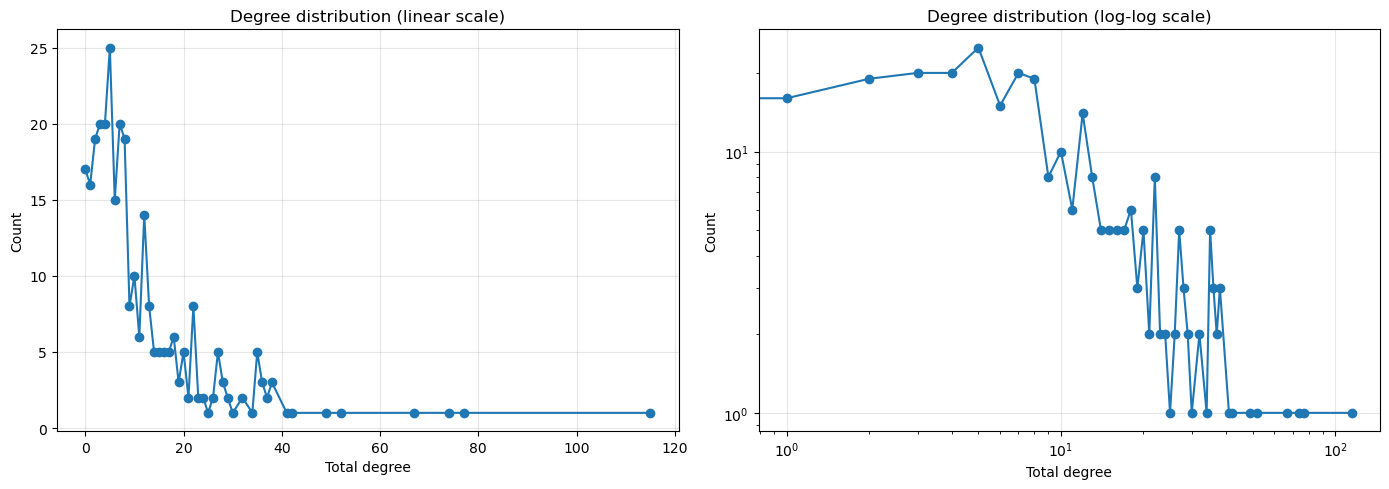

In [20]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Total degree of each node in the directed graph
total_degrees = [G.in_degree(node) + G.out_degree(node) for node in G.nodes()]
degree_counts = Counter(total_degrees)
x = np.array(sorted(degree_counts.keys()), dtype=float)
y = np.array([degree_counts[d] for d in x], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, y, marker='o', linestyle='-')
axes[0].set_title('Degree distribution (linear scale)')
axes[0].set_xlabel('Total degree')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3)

axes[1].loglog(x, y, marker='o', linestyle='-')
axes[1].set_title('Degree distribution (log-log scale)')
axes[1].set_xlabel('Total degree')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Binned degree distribution

To make the degree structure easier to read, we also bin the total degree values into intervals. This smooths out small fluctuations and emphasizes the overall shape of the distribution. Comparing the binned versions on a linear scale and a log-log scale is often a good way to judge whether the network has a strong hub-and-spoke pattern or a more evenly spread structure.

Binned into 24 buckets with width 5.


AttributeError: Rectangle.set() got an unexpected keyword argument 's'

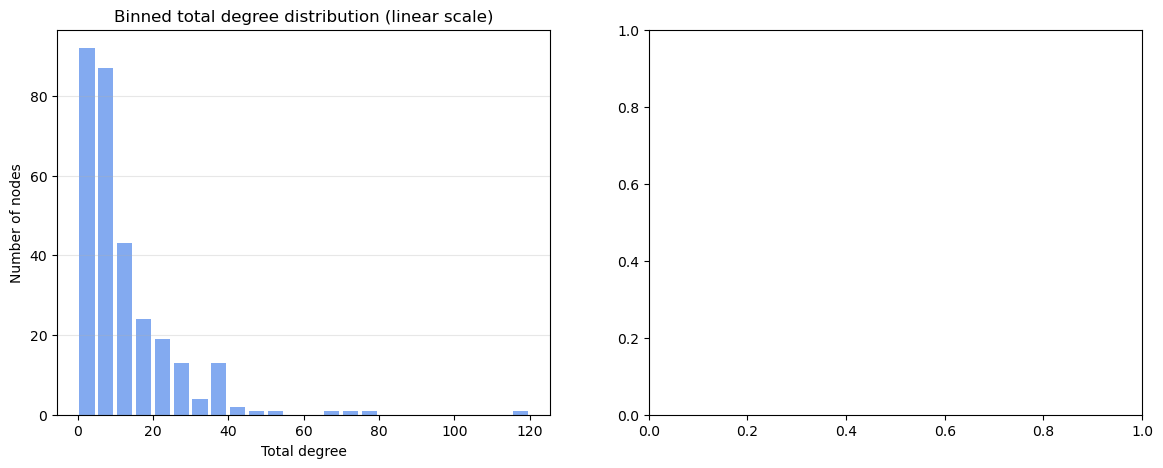

In [21]:
# Total degree of each node
total_degree = pd.Series([G.in_degree(node) + G.out_degree(node) for node in G.nodes()], name='total_degree')

# Binning for the distribution summary: aggregate degrees into wider buckets so the shape is visible
max_degree = int(total_degree.max())
bin_width = 5
bin_edges = np.arange(0, max_degree + bin_width + 1, bin_width)
hist_counts, hist_edges = np.histogram(total_degree, bins=bin_edges)
bin_mids = (hist_edges[:-1] + hist_edges[1:]) / 2
bin_vals = hist_counts.astype(float)

print(f'Binned into {len(bin_vals)} buckets with width {bin_width}.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(bin_mids, bin_vals, width=bin_width * 0.8, align='center', alpha=0.8, color='cornflowerblue')
axes[0].set_title('Binned total degree distribution (linear scale)')
axes[0].set_xlabel('Total degree')
axes[0].set_ylabel('Number of nodes')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(bin_mids, bin_vals, color='darkorange', s=40, alpha=0.9)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Binned total degree distribution (log-log scale)')
axes[1].set_xlabel('Total degree')
axes[1].set_ylabel('Number of nodes')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## In-degree versus out-degree

In a directed network like this one, being linked to by many others is not the same as linking out to many others. A character with a very high in-degree is often a major hub in the fandom or narrative universe, because many pages point toward them. A character with a high out-degree is more likely to connect broadly to many others, often because they are a gateway between different parts of the network. Comparing the two lets us understand which characters are central in different ways.

In [ ]:
import pandas as pd

in_degree = G.in_degree
out_degree = G.out_degree

in_df = pd.DataFrame([(node, in_degree(node), out_degree(node)) for node in G.nodes()], columns=['node', 'in_degree', 'out_degree'])

top_in = in_df.sort_values('in_degree', ascending=False).head(10)
top_out = in_df.sort_values('out_degree', ascending=False).head(10)

print('Top nodes by in-degree:')
print(top_in[['node', 'in_degree']].to_string(index=False))
print('Top nodes by out-degree:')
print(top_out[['node', 'out_degree']].to_string(index=False))

# Compare the two distributions
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(in_df['in_degree'], in_df['out_degree'], alpha=0.6, s=30)
ax.set_title('In-degree vs out-degree')
ax.set_xlabel('In-degree')
ax.set_ylabel('Out-degree')
ax.grid(alpha=0.3)

for _, row in top_in.head(3).iterrows():
    ax.annotate(row['node'], (row['in_degree'], row['out_degree']), xytext=(5, 5), textcoords='offset points', fontsize=8)

for _, row in top_out.head(3).iterrows():
    ax.annotate(row['node'], (row['in_degree'], row['out_degree']), xytext=(5, -10), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

## Drawing the network

A graph is easiest to interpret visually. Here we draw the directed network using a force-directed layout, which positions highly connected nodes closer together and leaves peripheral characters on the edges. The resulting picture is often revealing: a dense core of central heroes emerges, while many less-connected characters sit on the outside. This gives a first impression of the network's structure before we move on to more formal measures such as centrality and community detection.

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Importance measure for node size
degree_centrality = nx.degree_centrality(G)
sizes = [200 + 4000 * degree_centrality[n] for n in G.nodes()]

# Only label the most central heroes to keep the layout readable
top_nodes = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)[:20]
labels = {n: n.replace('_', ' ') for n in top_nodes}

pos = nx.kamada_kawai_layout(G)

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(
    G, pos,
    edge_color='lightgray',
    width=0.8,
    alpha=0.35,
    arrows=True,
    arrowstyle='-|>',
    ax=ax
)
nx.draw_networkx_nodes(
    G, pos,
    node_size=sizes,
    node_color=[degree_centrality[n] for n in G.nodes()],
    cmap='viridis',
    edgecolors='black',
    linewidths=0.5,
    alpha=0.85,
    ax=ax
)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold', ax=ax)

ax.set_axis_off()
ax.set_title('Marvel superhero wiki network (size = degree centrality)', fontsize=16)
plt.tight_layout()
plt.show()